# Donation-Intent Classifier Training — v13-Solo: Binary-Only Focus (Teacher-Directed)

Forks `capstone-v10-coda.ipynb` — the best individual result in the whole
project so far (RoBERTa binary macro-F1 = 0.834 on test, corroborated on
val at 0.8405 — see `architecture-v12.md` §1 for the full comparison
across v6/v9/v10/v11) — and removes the modifier head entirely, per the
course instructor's review: stop splitting model capacity and training
signal across two tasks when one of them (`modifier`) is fundamentally
data-starved (13 real source dialogues total for `conditional`, never
above ~0.45 F1 anywhere across v3-v12) and focus everything on making
the binary decision as good as it can be.

---

## What changes vs. v10-Coda, and why

**Architecture — same gated hierarchical encoder, one head instead of
two:**

- `self.modifier_head` is deleted. `forward()` returns `(binary_logits,
  shared)` instead of `(binary_logits, modifier_logits, shared)`. The
  cascaded modifier head's input concatenation (`[shared ;
  softmax(binary_logits)]`) obviously goes with it.
- The recency prior and last-Persuadee-turn gating from v10-Coda — the
  actual architectural idea being tested here — are carried over
  **unchanged**, so any change in binary performance is attributable to
  the head removal + capacity reinvestment below, not to a different
  gating mechanism.

**Capacity reinvestment — the freed parameters go to the one head that's
left:**

- `binary_head` is upgraded from a single `Linear(H, 2)` to the same
  2-layer MLP shape the deleted `modifier_head` used to have
  (`Linear(H, H/2) -> GELU -> Dropout -> Linear(H/2, 2)`) — literally the
  same capacity budget, redirected.
- `contrastive_weight_binary` goes from `0.10` to `0.30` (v10-Coda's
  `contrastive_weight_modifier` value) — the supervised-contrastive term
  now spends its whole budget shaping the representation for the binary
  decision, instead of splitting 0.10/0.30 across two tasks.
- Checkpoint selection now uses `val_binary_macro_f1` alone, not
  `(val_binary_macro_f1 + val_modifier_macro_f1_yes) / 2`. v10-Coda's
  averaged selection metric could pick a worse-for-binary epoch because a
  noisy 3-example-support modifier score happened to spike that epoch —
  this removes that noise from the one decision that matters now.

**Deliberately left unchanged, to keep this an isolated test of the head
removal:**

- Augmentation is v10-Coda's plain EDA, unchanged — including the
  minority-oversampling that used to target `conditional`/`deferred`
  (modifier-minority classes, all of which are `binary_label="yes"` by
  definition). **Honest caveat**: this now oversamples `yes`-labeled rows
  for a task (modifier) this notebook no longer scores, which skews the
  effective training distribution slightly further toward `yes` than the
  binary label's own imbalance would need. Retargeting augmentation at
  the binary-minority class (`no`) instead is a natural next experiment
  — not done here, so this run isolates the architectural change alone.
- All three encoders (RoBERTa, DeBERTa-v3, TOD-BERT) are still trained,
  same as v10-Coda — worth checking whether removing modifier's competing
  gradient signal changes which encoder comes out on top, not just
  RoBERTa's own number.
- OOM-safety settings for DeBERTa-v3 (`batch_size=2`, `eval_batch_size=4`,
  gradient checkpointing, `PYTORCH_CUDA_ALLOC_CONF`) are unchanged.

## What to check in the results

- Does RoBERTa's binary macro-F1 beat its own v10-Coda number (0.834)?
  If capacity reinvestment + a cleaner selection signal helped, it
  should move up, not just sideways.
- Does the *ranking* of the three encoders change now that DeBERTa-v3 and
  TOD-BERT aren't being dragged down by a modifier loss term they were
  never that good at (v10-Coda modifier F1|yes: 0.395 / 0.309)?
- `binary_accuracy`/`no`-class F1 specifically, given the honest caveat
  above about `yes`-skewed augmentation carrying over unchanged.


## 0b. Install / upgrade dependencies

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 546.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 672.9 kB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os
# Set BEFORE torch initializes its CUDA allocator -- mitigates the
# fragmentation-related OOM v6 hit on DeBERTa-v3 (see the intro cell for
# the failure and the fix rationale). Directly what the error message
# itself suggested.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as v3, so this works
    # unmodified whether the labeled CSV is added as a Kaggle Dataset
    # input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",
    # v13-solo writes its own output filenames (suffixed "_v13-solo") and
    # its own checkpoint subdirectory, so this can run in the same
    # out_dir as v3-v12 without clobbering their artifacts.
    "run_tag": "v13-solo",

    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    # Batch sizes are lower than v3/v4/v5's: the utterance encoder sees
    # batch_size * (turns/dialogue, ~20 typical, up to 32) flattened
    # sequences per forward pass instead of batch_size whole dialogues,
    # so effective memory pressure is much higher per training step even
    # though each individual sequence is short.
    #
    # FIX (post-OOM): the first v6 run OOM'd on DeBERTa-v3 -- it crashed
    # before completing epoch 1 with 14.13/14.56 GiB already allocated on
    # a T4, even at batch_size=4 (RoBERTa completed its full run fine at
    # batch_size=8, reaching val_binary_macroF1=0.80 / modifier_macroF1|
    # yes=0.67 before the crash on the next encoder -- see the intro cell).
    # DeBERTa-v2/v3's disentangled attention builds extra O(L^2)
    # content-to-position/position-to-content bias tensors per layer that
    # RoBERTa/BERT-style attention doesn't, so it needs a much larger cut
    # here than it did for the flat model in v3/v4/v5 (batch_size=8 there
    # was enough; the B*U flattening here multiplies that pressure).
    # batch_size=2 (down from the failing 4) plus gradient checkpointing
    # (enabled unconditionally below, for all three encoders) should give
    # a large safety margin. eval_batch_size is overridden down too --
    # even under torch.no_grad(), a flattened [B*U, L] forward pass at
    # DeBERTa's per-token memory cost adds up at eval_batch_size=16.
    # If this still OOMs, the next lever to pull is batch_size=1.
    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base",          "batch_size": 8},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base", "lr": 5e-6, "batch_size": 2, "eval_batch_size": 4, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1", "batch_size": 8},
    ],

    # Per-utterance token budget and max turns/dialogue. The real corpus
    # never exceeds 30 turns/dialogue (p95=23, p99=25) and 98.7% of
    # individual turns are under 64 words, so these give full headroom
    # with truncation essentially never firing (see the v6 intro cell for
    # the measured distribution).
    "max_utterances": 32,
    "max_utt_len": 64,

    # Dialogue-level Transformer (encodes discourse structure across the
    # sequence of turn vectors). README's HiTrans sketch suggests 6
    # layers; defaulting lower here since this dataset is small (~1000
    # augmented training dialogues) and a deep transformer over only
    # ~20 turn-vectors per example risks overfitting/instability faster
    # than it helps -- bump this if you have the compute budget to check.
    "dialogue_num_layers": 4,
    "dialogue_num_heads": 8,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 8,
    "eval_batch_size": 16,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    # v13-solo: no modifier_loss_weight -- there is no modifier task
    # left to weight. binary_loss_weight kept for readability even
    # though it is now the only term compute_losses() ever applies.
    "binary_loss_weight": 1.0,

    # Data augmentation (EDA, kept from v3, unchanged) -----------------
    "use_augmentation": True,
    "aug_alpha": 0.15,
    "aug_num_conditional": 6,
    "aug_num_deferred": 2,
    "aug_num_no": 1,
    # v5: bias synonym-replacement/insertion toward Persuadee-turn
    # tokens (0.0 = fully uniform like v3/v4, 1.0 = Persuadee tokens
    # always tried first). Labels are defined entirely by what the
    # Persuadee says (guideline.md), so this spends more of the
    # perturbation budget where the signal actually is.
    "aug_persuadee_bias_weight": 0.75,

    # ---- v4: Class-Balanced Focal Loss (replaces v3's inverse-freq
    # weighted CE + label smoothing) --------------------------------
    # "Class-Balanced Loss Based on Effective Number of Samples"
    # (Cui et al., 2019, CVPR). beta close to 1 -> weight ~ inverse
    # frequency for well-populated classes but saturates gracefully for
    # near-zero-sample classes (e.g. conditional) instead of exploding.
    "cb_beta": 0.999,
    # Focal-loss focusing parameter: down-weights already-easy/confident
    # predictions so the loss keeps pushing on hard/minority examples
    # for the whole run, not just at initialisation.
    "focal_gamma": 2.0,

    # ---- v4: Supervised Contrastive auxiliary loss --------------------
    # In-batch, single-stage (no separate pretraining pass -> cheap).
    # Pulls same-class pooled representations together / pushes apart.
    # v13-solo: the whole contrastive budget now goes to binary --
    # this is v10-coda's contrastive_weight_modifier value, moved
    # over rather than split, since there is only one task left.
    "use_contrastive": True,
    "contrastive_temperature": 0.1,
    "contrastive_weight_binary": 0.30,

    "early_stopping_patience": 5,
    "checkpoint_dir_name": "checkpoints_v13-solo",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])

Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "run_tag": "v13-solo",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_utterances": 32,
  "max_utt_len": 64,
  "dialogue_num_layers": 4,
  "dialogue_num_heads": 8,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 8,
  "eval_batch_size": 16,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "use_augmentation": true,
  "aug_alpha": 0.15,
  "aug_num_conditional": 6,
  "aug_num_deferred": 2,
  "aug_num_no": 1,
  "aug_persuadee_bias_weight": 0.75,
  "cb_beta": 

## 2. Load the labeled dataset

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING  (unchanged from v3)
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the labeled dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
df.head()

Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


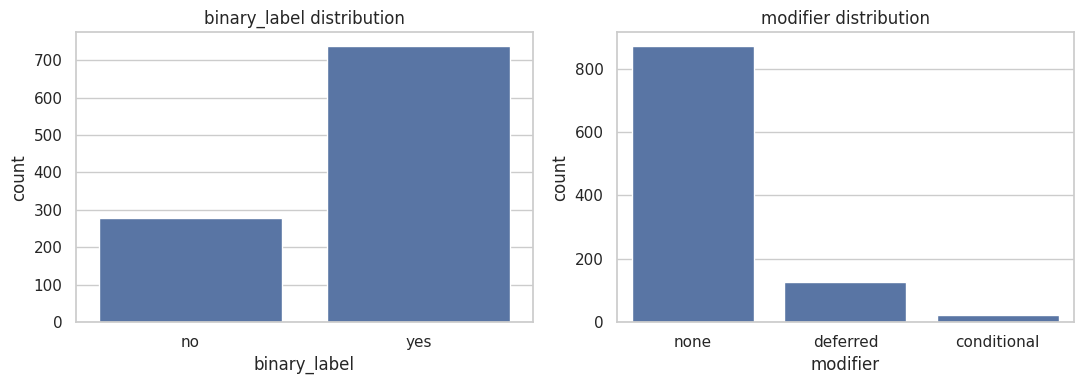


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE  (unchanged from v3)
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)

## 3. Stratified 70/15/15 train/val/test split

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination) -- unchanged from v3
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 3b. Data Augmentation (EDA) — TRAIN SPLIT ONLY (v5: fixed)

In [6]:
# =============================================================
# 3b. EDA AUGMENTATION (train split only, label-safety-guarded)  -- v5 FIXES:
#   1. marker-safe tokenizer (regex, not text.split(" "))
#   2. hashlib-based deterministic seeding (not Python's randomized hash())
#   3. Persuadee-turn-biased synonym replacement / insertion
# =============================================================
import re
import random as _random
import hashlib

PROTECTED_WORDS = {
    "if", "unless", "provided", "as", "long", "condition", "conditional",
    "after", "once", "later", "when", "then", "next", "eventually",
    "promise", "will", "would", "could", "might", "may", "maybe",
    "paycheck", "payday", "month", "week", "tomorrow", "soon",
    "not", "no", "never", "don't", "dont", "won't", "wont", "can't", "cant",
    "donate", "donation", "give", "money", "charity", "pledge",
}
SPEAKER_MARKERS = {"[persuader]", "[persuadee]"}

_SYNONYMS = {
    "good": ["nice", "great", "fine", "decent"],
    "really": ["truly", "genuinely", "honestly"],
    "think": ["believe", "feel", "figure"],
    "want": ["would like", "wish", "hope"],
    "help": ["assist", "support", "aid"],
    "people": ["folks", "individuals", "persons"],
    "important": ["significant", "vital", "essential"],
    "cause": ["mission", "campaign", "effort"],
    "understand": ["see", "get", "realize"],
    "sure": ["certain", "confident", "positive"],
    "sorry": ["apologies", "regret", "my bad"],
    "okay": ["alright", "fine", "sure"],
    "thanks": ["thank you", "appreciate it", "cheers"],
    "great": ["awesome", "wonderful", "fantastic"],
    "kids": ["children", "youth", "young ones"],
    "families": ["households", "homes"],
    "problem": ["issue", "trouble", "difficulty"],
    "talk": ["chat", "speak", "discuss"],
    "guess": ["suppose", "reckon", "figure"],
    "job": ["work", "career", "position"],
    "busy": ["swamped", "occupied", "tied up"],
}

def _get_synonym(word):
    lw = word.lower()
    if lw in _SYNONYMS:
        return _random.choice(_SYNONYMS[lw])
    return None

# v5 FIX 1: [Persuader]/[Persuadee] matched as their own atomic token
# FIRST, regardless of what they're glued to. v3/v4 used text.split(" "),
# which only isolates a marker when it happens to already be
# space-delimited -- empirically true for only ~42% of markers in this
# corpus; the other ~58% are glued straight onto "\n" or the previous
# word (e.g. "today?\n[Persuadee]"), so the marker-protection check never
# matched them and they were exposed to swap/delete corruption.
_TOKEN_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]|\S+')

def _tokenize_protecting_markers(text):
    return _TOKEN_PATTERN.findall(text)

def _is_locked(tok):
    low = tok.strip(".,!?;:\"'").lower()
    return low in PROTECTED_WORDS or low in SPEAKER_MARKERS or tok.lower() in SPEAKER_MARKERS

def _tag_token_roles(words):
    """Tag each token with its enclosing speaker turn ('persuader' /
    'persuadee' / 'other' before the first marker). Used only to bias
    WHICH words augmentation prefers to touch -- has no effect on the
    actual model's speaker-role embedding, which in v6 is assigned per
    TURN by split_into_utterances() further down (v4/v5's token-level
    compute_batch_role_ids() is not used in this hierarchical model)."""
    roles = []
    current = "other"
    for w in words:
        low = w.lower()
        if low == "[persuader]":
            current = "persuader"
        elif low == "[persuadee]":
            current = "persuadee"
        roles.append(current)
    return roles

def _ranked_candidates(indices, roles, bias_weight):
    """Order candidate indices so Persuadee-turn ones are tried first with
    probability bias_weight -- never excludes Persuader-turn candidates
    outright, since short conditional/deferred dialogues can be almost
    entirely one speaker's words."""
    persuadee = [i for i in indices if roles[i] == "persuadee"]
    other = [i for i in indices if roles[i] != "persuadee"]
    _random.shuffle(persuadee)
    _random.shuffle(other)
    if _random.random() < bias_weight:
        return persuadee + other
    return other + persuadee

def eda_synonym_replacement(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words) if not _is_locked(w) and _get_synonym(w)]
    if roles is not None and bias_weight > 0:
        candidates = _ranked_candidates(candidates, roles, bias_weight)
    else:
        _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        syn = _get_synonym(new_words[idx])
        if syn:
            new_words[idx] = syn
            replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_random_deletion(words, p):
    # Role-agnostic on purpose (see v5 intro cell): deletion is structural
    # noise/shortening, not phrasing diversity, and Persuadee turns can be
    # very short already in conditional/deferred rows.
    if len(words) <= 3:
        return words.copy()
    new_words = []
    for w in words:
        if _is_locked(w):
            new_words.append(w)
        elif _random.random() > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [words[_random.randrange(len(words))]]
    return new_words

def eda_random_swap(words, n):
    # Role-agnostic on purpose -- see eda_random_deletion above.
    new_words = words.copy()
    swappable = [i for i, w in enumerate(new_words) if not _is_locked(w)]
    for _ in range(n):
        if len(swappable) < 2:
            break
        i, j = _random.sample(swappable, 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_random_insertion(words, n, roles=None, bias_weight=0.0):
    # Source word to duplicate-as-synonym is chosen from the ORIGINAL
    # (fixed) word/role list, not the growing new_words list -- keeps
    # role-index alignment simple and correct as the list grows.
    new_words = words.copy()
    base_candidates = [i for i, w in enumerate(words) if not _is_locked(w) and _get_synonym(w)]
    for _ in range(n):
        if not base_candidates:
            break
        if roles is not None and bias_weight > 0:
            idx = _ranked_candidates(base_candidates, roles, bias_weight)[0]
        else:
            idx = _random.choice(base_candidates)
        syn = _get_synonym(words[idx])
        insert_pos = _random.randrange(len(new_words) + 1)
        new_words.insert(insert_pos, syn)
    return new_words

def eda_augment_one(text, alpha=0.15, seed=None, bias_weight=0.0):
    if seed is not None:
        _random.seed(seed)
    words = _tokenize_protecting_markers(text)
    roles = _tag_token_roles(words) if bias_weight > 0 else None
    n_ops = max(1, int(alpha * len(words)))

    op = _random.choice(["synonym", "swap", "delete", "insert"])
    if op == "synonym":
        words = eda_synonym_replacement(words, n_ops, roles=roles, bias_weight=bias_weight)
    elif op == "swap":
        words = eda_random_swap(words, n_ops)
    elif op == "delete":
        words = eda_random_deletion(words, p=alpha)
    else:
        words = eda_random_insertion(words, n_ops, roles=roles, bias_weight=bias_weight)

    return " ".join(words)

# v5 FIX 2: hashlib-based deterministic seed, stable across processes/runs.
# Python's built-in hash() on strings is randomized per-process
# (PYTHONHASHSEED) -- v3/v4's seed=hash((text, k)) % (2**31) silently
# produced different augmented text on every kernel restart despite
# CONFIG["SEED"] being fixed. sha256 is stable by construction.
def _stable_seed(*parts):
    h = hashlib.sha256("::".join(str(p) for p in parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

def augment_dataframe_for_minority_classes(df, config, seed=42):
    _random.seed(seed)
    rows_to_add = []
    bias_weight = config.get("aug_persuadee_bias_weight", 0.0)

    yes_idx = config["binary_classes"].index("yes")
    no_idx = config["binary_classes"].index("no")
    cond_idx = config["modifier_classes"].index("conditional")
    def_idx = config["modifier_classes"].index("deferred")

    plan = [
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == cond_idx), config["aug_num_conditional"],
        (df["binary_id"] == yes_idx) & (df["modifier_id"] == def_idx),  config["aug_num_deferred"],
        (df["binary_id"] == no_idx),                                   config["aug_num_no"],
    ]
    for mask, n_copies in zip(plan[0::2], plan[1::2]):
        subset = df.loc[mask]
        for _, row in subset.iterrows():
            for k in range(n_copies):
                aug_text = eda_augment_one(row["text"], alpha=config["aug_alpha"],
                                            seed=_stable_seed(row["text"], k),
                                            bias_weight=bias_weight)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)

    if not rows_to_add:
        return df.reset_index(drop=True)

    aug_df = pd.DataFrame(rows_to_add)
    out = pd.concat([df, aug_df], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


if CONFIG.get("use_augmentation", False):
    _before_n = len(train_df)
    _before_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    train_df = augment_dataframe_for_minority_classes(train_df, CONFIG, seed=SEED)

    _after_n = len(train_df)
    _after_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    print(f"Train split size: {_before_n} -> {_after_n} rows after EDA augmentation")
    print("\nmodifier distribution among binary=yes TRAIN rows, before -> after:")
    display(pd.concat({"before": _before_dist, "after": _after_dist}, axis=1).fillna(0).astype(int))
    print("\nbinary_label distribution after augmentation:")
    print(train_df["binary_label"].value_counts())
else:
    print("Augmentation disabled (CONFIG['use_augmentation'] = False).")

Train split size: 711 -> 1055 rows after EDA augmentation

modifier distribution among binary=yes TRAIN rows, before -> after:


,before,after
modifier,,
none,459,459
deferred,47,141
conditional,9,63



binary_label distribution after augmentation:
binary_label
yes    663
no     392
Name: count, dtype: int64


### 3c. Augmentation QA — marker-integrity self-check (new in v5)

Runs the fixed augmentation against every training row and checks that the number of `[Persuader]`/`[Persuadee]` markers is preserved. On v3/v4's tokenizer this failed on 15.9% of variants; expect ~0% here.

In [7]:
# =============================================================
# 3c. AUGMENTATION QA -- marker-integrity self-check (v5)
# =============================================================
_marker_pattern = re.compile(r'\[Persuader\]|\[Persuadee\]')

def _marker_count(t):
    return len(_marker_pattern.findall(t))

_n_checked = 0
_n_mismatch = 0
_mismatch_examples = []
_bias_weight = CONFIG.get("aug_persuadee_bias_weight", 0.0)

for _, _row in train_df.iterrows():
    _orig_markers = _marker_count(_row["text"])
    if _orig_markers == 0:
        continue
    for _k in range(3):
        _aug_text = eda_augment_one(_row["text"], alpha=CONFIG["aug_alpha"],
                                     seed=_stable_seed(_row["text"], f"qa{_k}"),
                                     bias_weight=_bias_weight)
        _aug_markers = _marker_count(_aug_text)
        _n_checked += 1
        if _aug_markers != _orig_markers:
            _n_mismatch += 1
            if len(_mismatch_examples) < 3:
                _mismatch_examples.append((_orig_markers, _aug_markers, _row["text"][:100], _aug_text[:100]))

print(f"Checked {_n_checked} augmented variants across {len(train_df)} (post-augmentation) train rows.")
print(f"Marker-count mismatches: {_n_mismatch} ({_n_mismatch / max(_n_checked, 1):.2%})")
if _mismatch_examples:
    print("\nExample mismatches:")
    for _o, _a, _ot, _at in _mismatch_examples:
        print(f"  orig_markers={_o} aug_markers={_a}\n    ORIG: {_ot!r}\n    AUG : {_at!r}")
else:
    print("No marker corruption detected.")


Checked 3165 augmented variants across 1055 (post-augmentation) train rows.
Marker-count mismatches: 0 (0.00%)
No marker corruption detected.


## 4. Dataset, utterance splitting & hierarchical batching (v6)

In [8]:
# =============================================================
# 4. TORCH DATASET + UTTERANCE SPLITTING + HIERARCHICAL COLLATE  (v6)
# =============================================================
import re

_SPEAKER_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]')
ROLE_PERSUADER = 0
ROLE_PERSUADEE = 1
ROLE_PAD       = 2   # padding turn-slot (dialogue shorter than batch max)


class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def split_into_utterances(text, max_utterances=32):
    """
    Split a dialogue into (speaker_role, utterance_text) turns using
    [Persuader]/[Persuadee] markers located by regex POSITION -- not
    text.split(" ") -- so this is robust regardless of whether a marker
    is glued to surrounding whitespace/punctuation (57.5% of markers in
    this corpus are glued to a preceding "\n" with no space; see v5's
    augmentation fix for the full measurement).

    If a dialogue has more than max_utterances turns, the EARLIEST turns
    are dropped and the most recent max_utterances are kept -- donation
    intent is usually resolved near the end of a conversation
    (guideline.md: "use the persuadee's last clear position"). In
    practice this corpus never exceeds 30 turns, so with the default
    max_utterances=32 this branch does not fire.
    """
    matches = list(_SPEAKER_PATTERN.finditer(text))
    utterances = []
    for i, m in enumerate(matches):
        role = ROLE_PERSUADER if m.group() == "[Persuader]" else ROLE_PERSUADEE
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt_text = text[start:end].strip()
        if utt_text:
            utterances.append((role, utt_text))
    if len(utterances) > max_utterances:
        utterances = utterances[-max_utterances:]
    return utterances


def make_hier_collate_fn(tokenizer, max_utt_len, max_utterances):
    """
    Builds a batch of shape [B, U, L] (U = max turns present in this
    batch, L = max tokens across all turns in this batch, both dynamic --
    not padded to the global max_utterances/max_utt_len caps) plus:
      - utt_mask [B, U]  : 1 = real turn, 0 = padding turn-slot
      - role_ids [B, U]  : ROLE_PERSUADER / ROLE_PERSUADEE / ROLE_PAD

    Padding turn-slots (dialogues shorter than this batch's U) get a
    single valid dummy token (the tokenizer's CLS/BOS id, attention_mask=1
    at position 0 only) rather than an all-zero attention mask -- avoids
    relying on every encoder implementation handling a fully-masked
    sequence identically; utt_mask excludes these slots from both the
    dialogue transformer (src_key_padding_mask) and the final attention
    pooling, so their (unused) encoded vector never reaches the heads.
    """
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    cls_id = tokenizer.cls_token_id
    if cls_id is None:
        cls_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else pad_id

    def collate_fn(batch):
        all_utts = []
        for b in batch:
            utts = split_into_utterances(b["text"], max_utterances=max_utterances)
            if not utts:
                utts = [(ROLE_PERSUADEE, "")]   # degenerate fallback, should not occur on this corpus
            all_utts.append(utts)

        B = len(all_utts)
        U = max(len(u) for u in all_utts)

        flat_texts, flat_roles, owner = [], [], []
        for di, utts in enumerate(all_utts):
            for ui, (role, text) in enumerate(utts):
                flat_texts.append(text if text.strip() else " ")
                flat_roles.append(role)
                owner.append((di, ui))

        enc = tokenizer(flat_texts, padding=True, truncation=True,
                         max_length=max_utt_len, return_tensors="pt")
        L = enc["input_ids"].shape[1]

        input_ids = torch.full((B, U, L), pad_id, dtype=torch.long)
        attn_mask = torch.zeros(B, U, L, dtype=torch.long)
        utt_mask  = torch.zeros(B, U, dtype=torch.long)
        role_ids  = torch.full((B, U), ROLE_PAD, dtype=torch.long)

        input_ids[:, :, 0] = cls_id   # safe dummy token everywhere, overwritten below for real turns

        for flat_idx, (di, ui) in enumerate(owner):
            input_ids[di, ui] = enc["input_ids"][flat_idx]
            attn_mask[di, ui] = enc["attention_mask"][flat_idx]
            utt_mask[di, ui] = 1
            role_ids[di, ui] = flat_roles[flat_idx]

        pad_slot = (utt_mask == 0)
        attn_mask[:, :, 0] = attn_mask[:, :, 0].masked_fill(pad_slot, 1)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "utt_mask": utt_mask,
            "role_ids": role_ids,
            "binary_labels":   torch.tensor([b["binary_id"]   for b in batch], dtype=torch.long),
            "modifier_labels": torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long),
        }
    return collate_fn

## 5. Model architecture — hierarchical encoder + last-turn gating (v10-coda, README idea #9)

```
input_ids, attention_mask   [B, U, L]
        |
   flatten [B*U, L], ONE batched forward pass through the shared
   utterance encoder (RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
        |
   masked mean-pool each turn -> [B*U, H] -> reshape [B, U, H]
        |
   +--(+)-- Speaker-Role Embedding   nn.Embedding(3, H)
   +--(+)-- Turn-Position Embedding  nn.Embedding(max_utterances, H)
        |
   Dialogue Transformer (4 layers, batch_first=True)
   src_key_padding_mask = ~utt_mask
        |
        +----------------------------------------------------+
        |                                                     |
   Turn-Attention Pooling                              Last-Persuadee-Turn Readout   <- NEW (idea #9)
   score_t = w^T tanh(W h_t) + recency_bias(t)                u_last = dialogue_hidden[b, last_persuadee_idx]
   recency_bias(t) = recency_strength * (t / (U-1))           (falls back to the dialogue's last real
   [learned scalar, init 0.0 -> starts as a no-op]              turn of any role if somehow no
   pooled = softmax(score)-weighted sum over turns              Persuadee turn exists)
        |                                                     |
        +----------------------------------------------------+
                              |
                    Gated Residual Fusion    <- NEW (idea #9)
              gate = sigmoid(Linear([pooled ; u_last]))
              gate.bias init +3.0 -> sigmoid≈0.95 -> shared≈pooled initially (= v6's behavior)
              shared = gate * pooled + (1 - gate) * u_last
                              |
                +-------------+-------------+
                |                           |
          binary_head                 modifier_head          (cascaded, unchanged from v6)
                |                           |
          binary_logits             modifier_logits
```

Why each piece, and why initialized as a no-op:

- **Recency prior** is one learned scalar (`nn.Parameter`, init `0.0`)
  added to the existing attention-pooling scores as a linear ramp over
  turn position — `0` at the first turn, `recency_strength` at the last.
  At initialization it contributes nothing; training can push it positive
  (favor later turns generally) if that helps, or leave it near zero.
- **Last-turn gating** reads out `dialogue_hidden` at the index of the
  dialogue's last real Persuadee turn — found via `role_ids`/`utt_mask`,
  the same tensors already computed for the role/position embeddings, no
  new inputs needed. This is a *hard* guarantee the closing stance is
  available to the classifier, complementing the *soft* recency prior
  above (which only reweights what attention pooling already sees).
- **Gate bias initialized to `+3.0`** (`sigmoid(3.0) ≈ 0.95`) so
  `shared ≈ pooled` at the start of training — matching v6's exact
  behavior initially, the same "start near the known-good baseline"
  principle already used for the role/position embeddings' small-std
  init. Training decides whether leaning on `u_last` actually helps.

In [9]:
# =============================================================
# 5. HIERARCHICAL ENCODER + LAST-PERSUADEE-TURN GATING  (v10-coda architecture,
#    binary-only per v13-solo -- modifier head removed, see intro cell)
# =============================================================

class HierarchicalDialogueClassifier(nn.Module):
    """
    Two-level encoder (unchanged from v6: turn-level encoding + dialogue
    Transformer), plus two new mechanisms from README idea #9:

    1. Recency prior: a learned scalar biases the turn-attention-pooling
       scores toward later turns (linear ramp over turn position),
       initialized at 0.0 so it starts as a complete no-op.
    2. Last-Persuadee-Turn gating: a learned sigmoid gate blends the
       attention-pooled summary with the dialogue transformer's own
       hidden vector at the dialogue's last real Persuadee turn. The
       gate's bias is initialized to +3.0 (sigmoid~0.95) so the model
       starts out behaving like v6 (shared ~= pooled) and only leans on
       the last-turn vector if training finds that helps.

    Returns (binary_logits, shared_repr) -- v13-solo drops the modifier
    head entirely, so this is a 2-tuple, not v10-coda's 3-tuple.
    """

    NUM_ROLES = 3  # Persuader / Persuadee / pad
    ROLE_PERSUADEE_ID = 1  # matches ROLE_PERSUADEE defined in the dataset/collate cell above

    def __init__(self, hf_id, n_binary, dropout=0.1,
                 dialogue_layers=4, dialogue_heads=8, max_utterances=32):
        super().__init__()
        self.utt_encoder = AutoModel.from_pretrained(hf_id)
        # Gradient checkpointing (unchanged from v6's OOM fix) -- trades
        # ~20-30% extra compute for a large cut in activation memory.
        if hasattr(self.utt_encoder, "gradient_checkpointing_enable"):
            self.utt_encoder.gradient_checkpointing_enable()
        hidden = self.utt_encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        self.role_embedding = nn.Embedding(self.NUM_ROLES, hidden)
        nn.init.normal_(self.role_embedding.weight, std=0.02)
        self.pos_embedding = nn.Embedding(max_utterances, hidden)
        nn.init.normal_(self.pos_embedding.weight, std=0.02)

        dialogue_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=dialogue_heads, dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu", batch_first=True)
        self.dialogue_transformer = nn.TransformerEncoder(dialogue_layer, num_layers=dialogue_layers)

        self.attn_proj  = nn.Linear(hidden, hidden)
        self.attn_score = nn.Linear(hidden, 1, bias=False)

        # v10-coda NEW: recency prior -- one learned scalar, starts inert.
        self.recency_strength = nn.Parameter(torch.tensor(0.0))

        # v10-coda NEW: last-Persuadee-turn gate. Bias initialized high so
        # sigmoid(gate) starts near 1.0 -> shared starts ~= pooled (v6's
        # exact behavior), not a 50/50 blend of two initially-random signals.
        self.gate_linear = nn.Linear(hidden * 2, hidden)
        nn.init.zeros_(self.gate_linear.weight)
        nn.init.constant_(self.gate_linear.bias, 3.0)

        # v13-solo: binary_head upgraded to the same 2-layer MLP shape the
        # deleted modifier_head used to have -- same capacity budget,
        # now spent entirely on the one head that's left.
        self.binary_head = nn.Sequential(
            nn.Linear(hidden, max(hidden // 2, n_binary)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden // 2, n_binary), n_binary),
        )

    def _encode_turns(self, input_ids, attention_mask):
        """[B, U, L] -> [B, U, H] via one flattened forward pass through
        the shared utterance encoder + masked mean-pool per turn."""
        B, U, L = input_ids.shape
        flat_ids  = input_ids.view(B * U, L)
        flat_mask = attention_mask.view(B * U, L)

        outputs = self.utt_encoder(input_ids=flat_ids, attention_mask=flat_mask)
        flat_hidden = outputs.last_hidden_state             # [B*U, L, H]

        mask = flat_mask.unsqueeze(-1).float()
        summed = (flat_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        turn_vecs = summed / counts                          # [B*U, H]

        return turn_vecs.view(B, U, -1)

    def _attention_pool(self, hidden, mask):
        """Learned attention pooling over the turn dimension, with a
        learned recency bias added to the scores before the softmax
        (v10-coda NEW). `mask`: 1 = real turn, 0 = padding turn-slot."""
        scores = self.attn_score(torch.tanh(self.attn_proj(hidden))).squeeze(-1)  # [B, U]

        U = hidden.shape[1]
        positions = torch.arange(U, device=hidden.device, dtype=scores.dtype)
        recency_bias = self.recency_strength * (positions / max(U - 1, 1))        # [U]
        scores = scores + recency_bias.unsqueeze(0)

        scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (hidden * weights).sum(dim=1)

    def _last_persuadee_index(self, role_ids, utt_mask):
        """For each item in the batch, the index of the LAST turn that is
        both a real turn (utt_mask=1) and spoken by the Persuadee
        (role_ids == ROLE_PERSUADEE_ID). Falls back to the last real turn
        of any role if a dialogue somehow has no Persuadee turn (should
        not happen on this corpus, but keeps this from ever indexing
        into a padding position)."""
        B, U = role_ids.shape
        idx_range = torch.arange(U, device=role_ids.device).unsqueeze(0).expand(B, U)

        is_persuadee_valid = (role_ids == self.ROLE_PERSUADEE_ID) & (utt_mask == 1)
        persuadee_idx = torch.where(is_persuadee_valid, idx_range,
                                     torch.full_like(idx_range, -1)).max(dim=1).values

        is_valid = utt_mask == 1
        any_valid_idx = torch.where(is_valid, idx_range,
                                     torch.full_like(idx_range, -1)).max(dim=1).values

        last_idx = torch.where(persuadee_idx >= 0, persuadee_idx, any_valid_idx)
        return last_idx.clamp(min=0)

    def forward(self, input_ids, attention_mask, utt_mask, role_ids, **_):
        B, U, L = input_ids.shape

        turn_vecs = self._encode_turns(input_ids, attention_mask)     # [B, U, H]
        turn_vecs = turn_vecs + self.role_embedding(role_ids)

        positions = torch.arange(U, device=turn_vecs.device).unsqueeze(0).expand(B, U)
        turn_vecs = turn_vecs + self.pos_embedding(positions)

        key_padding_mask = (utt_mask == 0)
        dialogue_hidden = self.dialogue_transformer(
            turn_vecs, src_key_padding_mask=key_padding_mask)         # [B, U, H]

        pooled = self._attention_pool(dialogue_hidden, utt_mask)      # [B, H] -- recency-biased

        last_idx = self._last_persuadee_index(role_ids, utt_mask)     # [B]
        batch_idx = torch.arange(B, device=dialogue_hidden.device)
        u_last = dialogue_hidden[batch_idx, last_idx]                 # [B, H]

        gate = torch.sigmoid(self.gate_linear(torch.cat([pooled, u_last], dim=-1)))  # [B, H]
        gated = gate * pooled + (1.0 - gate) * u_last

        shared = self.dropout(gated)

        binary_logits = self.binary_head(shared)

        return binary_logits, shared

## 6. Loss — Class-Balanced Focal Loss + Supervised Contrastive (unchanged from v4/v5)

Replaces v3's `CrossEntropyLoss(weight=inverse_freq, label_smoothing=0.1)`
on both heads.

**Class-Balanced Focal Loss** (Cui et al., 2019, CVPR): class weights come
from the *effective number of samples* `(1 - beta^n) / (1 - beta)` rather
than raw inverse frequency — this saturates gracefully for near-zero-sample
classes like `conditional` (~9-13 real train rows) instead of assigning an
enormous, unstable weight. On top of that, the focal term
`(1-p_t)^gamma` keeps discounting *already-easy* predictions for the whole
run, so a model that starts predicting the majority class confidently
doesn't get to coast on a fixed loss scale the way plain weighted CE
allows.

**Supervised Contrastive loss** (Khosla et al., 2020), computed in-batch
on `shared_repr`: for each anchor with at least one same-class partner in
the batch, pulls same-class pooled vectors together and pushes different-
class ones apart via a batch similarity matrix. This is a single-stage
stand-in for README idea #3 (full SimCSE needs an unsupervised
pretraining stage) — it adds one `B x B` matmul on vectors already
computed for the forward pass, so it is effectively free compute-wise.
Applied to binary labels (small weight) and, more heavily, to modifier
labels restricted to `binary_label == "yes"` rows (the class that
collapses hardest).

In [10]:
# =============================================================
# 6. CLASS-BALANCED FOCAL LOSS + SUPERVISED CONTRASTIVE LOSS  (v4)
# =============================================================

class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) class-balanced re-weighting (effective number of
    samples) combined with the focal-loss focusing term (Lin et al., 2017).
    """
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)  # avoid beta**0 edge case
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        loss = -alpha_t * (1 - pt).pow(self.gamma) * log_pt
        return loss.mean()


def supervised_contrastive_loss(pooled, labels, temperature=0.1):
    """
    In-batch supervised contrastive loss (Khosla et al., 2020), single-view.
    For each anchor with >=1 same-class partner in the batch, pulls its
    representation toward same-class partners and away from the rest.
    Anchors with zero same-class partners in the batch contribute nothing
    (common in small batches with rare classes -- this is expected).
    """
    n = pooled.size(0)
    if n < 2:
        return torch.zeros((), device=pooled.device)

    z = F.normalize(pooled, dim=-1)
    sim = torch.matmul(z, z.T) / temperature                    # [B, B]

    labels = labels.view(-1, 1)
    same_class  = (labels == labels.T).float()
    self_mask   = torch.eye(n, device=z.device)
    positive_mask = same_class - self_mask

    logits_max, _ = sim.max(dim=1, keepdim=True)
    logits = sim - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - self_mask)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    pos_counts = positive_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.zeros((), device=pooled.device)

    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    return -mean_log_prob_pos.mean()


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # absent-in-train class: treat as 1 to avoid div issues
    return counts

binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

print("binary_label samples/class (train):", dict(zip(CONFIG["binary_classes"], binary_samples_per_class.tolist())))

binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])

print("\nClass-balanced weights (effective-number-of-samples, beta="
      f"{CONFIG['cb_beta']}):")
print("  binary:  ", dict(zip(CONFIG["binary_classes"], binary_focal_loss_fn.class_weights.tolist())))

binary_label samples/class (train): {'no': 392.0, 'yes': 663.0}

Class-balanced weights (effective-number-of-samples, beta=0.999):
  binary:   {'no': 1.198245644569397, 'yes': 0.8017544150352478}


## 7. Training / eval functions (v6)

Same shape as v4/v5 (class-balanced focal + supervised contrastive loss,
binary-macro-F1 checkpoint selection, val-tuned threshold search, early
stopping) — `compute_losses`, `evaluate`, and `find_optimal_binary_threshold`
are unchanged verbatim, since they only touch `(binary_logits,
modifier_logits, shared)` and label tensors, not the model's internals.
`train_one_encoder` is updated for: the hierarchical collate function,
the new model constructor arguments, and moving the extra `utt_mask` /
`role_ids` batch keys to device alongside the rest.

In [11]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS  (v13-solo: binary-only -- no modifier_logits,
#    no modifier_labels, no averaged selection metric)
# =============================================================

def compute_losses(binary_logits, shared, binary_labels, include_contrastive):
    """Shared loss computation used by both the training step and evaluate()."""
    binary_loss = binary_focal_loss_fn(binary_logits, binary_labels)
    total = CONFIG["binary_loss_weight"] * binary_loss

    if include_contrastive and CONFIG.get("use_contrastive", False):
        con_binary = supervised_contrastive_loss(
            shared, binary_labels, temperature=CONFIG["contrastive_temperature"])
        total = total + CONFIG["contrastive_weight_binary"] * con_binary

    return total


def evaluate(model, loader, device, binary_threshold=0.5):
    """
    Evaluate model on a DataLoader.

    binary_threshold : float
        P(yes) >= binary_threshold -> predict 'yes'.
    """
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_binary_probs = []
    total_loss = 0.0
    n_batches  = 0
    yes_idx    = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")  # unused -- no modifier head in v13-solo
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, shared = model(**batch)

            # Eval loss reported WITHOUT the contrastive term (it's a
            # representation-shaping regulariser for training, not a
            # meaningful "how good are these predictions" number).
            loss = compute_losses(binary_logits, shared, binary_labels,
                                   include_contrastive=False)
            total_loss += loss.item()
            n_batches  += 1

            binary_probs_yes = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            binary_preds     = (binary_probs_yes >= binary_threshold).long()

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_preds.cpu().tolist())
            all_binary_probs.extend(binary_probs_yes.cpu().tolist())

    binary_acc      = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1       = f1_score(all_binary_true, all_binary_pred, average="binary",
                                pos_label=yes_idx, zero_division=0)
    binary_macro_f1 = f1_score(all_binary_true, all_binary_pred, average="macro",
                                labels=[0, 1], zero_division=0)

    return {
        "loss":            total_loss / max(n_batches, 1),
        "binary_accuracy": binary_acc,
        "binary_f1":       binary_f1,
        "binary_macro_f1": binary_macro_f1,
        "binary_true":     all_binary_true,
        "binary_pred":     all_binary_pred,
        "binary_probs":    all_binary_probs,
    }


def find_optimal_binary_threshold(model, val_loader, device):
    """Grid-search for the binary threshold that maximises macro-F1 on val."""
    model.eval()
    all_true, all_probs = [], []
    yes_idx = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in val_loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, _ = model(**batch)
            probs = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            all_true.extend(binary_labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    best_threshold, best_macro_f1 = 0.5, 0.0
    for t in [v / 100 for v in range(10, 91, 5)]:
        preds    = [1 if p >= t else 0 for p in all_probs]
        macro_f1 = f1_score(all_true, preds, average="macro",
                             labels=[0, 1], zero_division=0)
        if macro_f1 > best_macro_f1:
            best_macro_f1, best_threshold = macro_f1, t

    return best_threshold, best_macro_f1


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id    = encoder_cfg["name"], encoder_cfg["hf_id"]
    sep_line       = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})  [binary-only]"
          f"  [hierarchical: max_utterances={CONFIG['max_utterances']}, "
          f"dialogue_layers={CONFIG['dialogue_num_layers']}]"
          f"  [contrastive={'ON' if CONFIG.get('use_contrastive') else 'OFF'}]\n{sep_line}")

    tokenizer  = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_hier_collate_fn(tokenizer, CONFIG["max_utt_len"],
                                       CONFIG["max_utterances"])

    train_ds = DonationIntentDataset(train_df)
    val_ds   = DonationIntentDataset(val_df)
    test_ds  = DonationIntentDataset(test_df)

    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    enc_eval_batch_size = encoder_cfg.get("eval_batch_size", CONFIG["eval_batch_size"])
    train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                               shuffle=True, collate_fn=collate_fn)
    val_loader  = DataLoader(val_ds,  batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=enc_eval_batch_size,
                              shuffle=False, collate_fn=collate_fn)

    model = HierarchicalDialogueClassifier(
        hf_id,
        n_binary=len(CONFIG["binary_classes"]),
        dialogue_layers=CONFIG["dialogue_num_layers"],
        dialogue_heads=CONFIG["dialogue_num_heads"],
        max_utterances=CONFIG["max_utterances"],
    ).to(DEVICE)

    yes_idx = CONFIG["binary_classes"].index("yes")

    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer  = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                                    weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * encoder_cfg.get("warmup_ratio", CONFIG["warmup_ratio"])),
        num_training_steps=total_steps,
    )

    ckpt_path            = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                                        f"{name}_best.pt")
    best_val_score       = -1.0
    epochs_without_improve = 0
    history              = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n}")

        for batch in pbar:
            binary_labels = batch.pop("binary_labels").to(DEVICE)
            batch.pop("modifier_labels")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, shared = model(**batch)

            loss = compute_losses(binary_logits, shared, binary_labels,
                                   include_contrastive=True)

            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE, binary_threshold=0.5)
        # v13-solo: selection metric is binary_macro_f1 alone -- no more
        # averaging with a noisy, low-support modifier score.
        val_score   = val_metrics["binary_macro_f1"]
        history.append({
            "epoch":               epoch,
            "train_loss":          running_loss / len(train_loader),
            "val_loss":            val_metrics["loss"],
            "val_binary_f1":       val_metrics["binary_f1"],
            "val_binary_macro_f1": val_metrics["binary_macro_f1"],
            "val_binary_accuracy": val_metrics["binary_accuracy"],
        })
        _tl = history[-1]["train_loss"]
        _bmf = val_metrics["binary_macro_f1"]
        print(f"  epoch {epoch}: train_loss={_tl:.4f} val_binary_macroF1={_bmf:.4f}")

        if val_score > best_val_score:
            best_val_score       = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (binary_macroF1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    best_thresh, thresh_val_macro_f1 = find_optimal_binary_threshold(
        model, val_loader, DEVICE)
    print(f"\n  Threshold search -> best thresh={best_thresh:.2f}"
          f"  (val macro-F1={thresh_val_macro_f1:.4f})")

    test_m_default = evaluate(model, test_loader, DEVICE, binary_threshold=0.5)
    test_m_tuned   = evaluate(model, test_loader, DEVICE, binary_threshold=best_thresh)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name":                 name,
        "hf_id":                hf_id,
        "history":              history,
        "test_metrics":         test_m_tuned,
        "test_metrics_default": test_m_default,
        "test_binary_accuracy": test_m_tuned["binary_accuracy"],
        "test_binary_f1":       test_m_tuned["binary_f1"],
        "test_binary_macro_f1": test_m_tuned["binary_macro_f1"],
        "best_threshold":       best_thresh,
        "ckpt_path":            ckpt_path,
    }


## 8. Run training for all three encoders

In [12]:
# =============================================================
# 8. RUN ALL THREE ENCODERS (binary-only)
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))


Training roberta-base (roberta-base)  [binary-only]  [hierarchical: max_utterances=32, dialogue_layers=4]  [contrastive=ON]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  epoch 6: train_loss=0.4116 val_binary_macroF1=0.7724


[todbert] epoch 7/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 7: train_loss=0.3750 val_binary_macroF1=0.7701


[todbert] epoch 8/25:   0%|          | 0/132 [00:00<?, ?it/s]

  epoch 8: train_loss=0.3793 val_binary_macroF1=0.7827
  -> no improvement for 5 epochs, stopping early.

  Threshold search -> best thresh=0.65  (val macro-F1=0.8544)

Done training all encoders: ['roberta-base', 'deberta-v3-base', 'todbert']


In [13]:
# =============================================================
# 8b. THRESHOLD COMPARISON TABLE
# =============================================================
print(f"\n{'='*70}")
print("Binary head: default threshold (0.5) vs val-tuned threshold")
print(f"{'='*70}")
header = f"{'Model':<20} {'Thresh':>6}  {'Binary Acc':>10}  {'Bin MacroF1':>11}  "
header += f"{'no F1':>8}  {'yes F1':>8}"
print(header)
print("-" * len(header))

for name, r in results.items():
    for label, tm, thresh in [
        ("(default)", r["test_metrics_default"], 0.5),
        ("(tuned)",   r["test_metrics"],         r["best_threshold"]),
    ]:
        from sklearn.metrics import f1_score as _f1
        no_f1  = _f1(tm["binary_true"], tm["binary_pred"], pos_label=0,
                      average="binary", zero_division=0)
        yes_f1 = _f1(tm["binary_true"], tm["binary_pred"], pos_label=1,
                      average="binary", zero_division=0)
        row = (f"{name+' '+label:<20} {thresh:>6.2f}  "
               f"{tm['binary_accuracy']:>10.4f}  {tm['binary_macro_f1']:>11.4f}  "
               f"{no_f1:>8.4f}  {yes_f1:>8.4f}")
        print(row)
    print()



Binary head: default threshold (0.5) vs val-tuned threshold
Model                Thresh  Binary Acc  Bin MacroF1     no F1    yes F1
------------------------------------------------------------------------
roberta-base (default)   0.50      0.8627       0.8145    0.7200    0.9091
roberta-base (tuned)   0.70      0.8693       0.8249    0.7368    0.9130

deberta-v3-base (default)   0.50      0.8366       0.7708    0.6479    0.8936
deberta-v3-base (tuned)   0.65      0.8366       0.7751    0.6575    0.8927

todbert (default)      0.50      0.8431       0.7969    0.7000    0.8938
todbert (tuned)        0.65      0.8105       0.7671    0.6667    0.8676



## 9. Test-set majority-class baseline (matched to the actual test split)

In [14]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
baseline_test_binary_pred = [train_majority_binary] * len(test_df)

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))


Majority-class baseline on TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.7254901960784313,
  "binary_f1": 0.8409090909090909,
  "binary_macro_f1": 0.42045454545454547
}


## 10. Results summary table — v13-solo (binary-only) vs. majority baseline


In [15]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "binary_macro_f1": r["test_binary_macro_f1"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], f"classifier_test_results_{CONFIG['run_tag']}.csv"), index=False)
display(summary_df)


,model,binary_accuracy,binary_f1,binary_macro_f1
0,majority_baseline,0.725490,0.840909,0.420455
1,roberta-base,0.869281,0.913043,0.824943
2,deberta-v3-base,0.836601,0.892704,0.775119
3,todbert,0.810458,0.867580,0.767123


### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

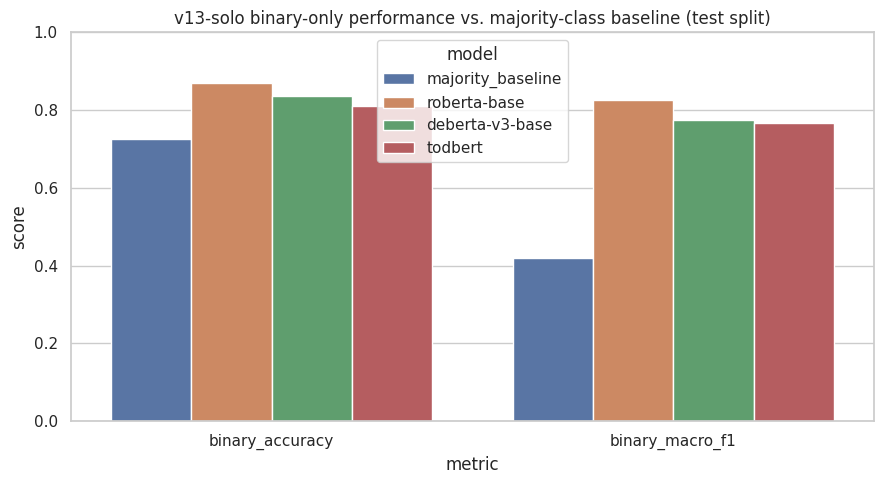

In [16]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("v13-solo binary-only performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"classifier_comparison_bar_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10b. Confusion matrices — binary_label, per encoder

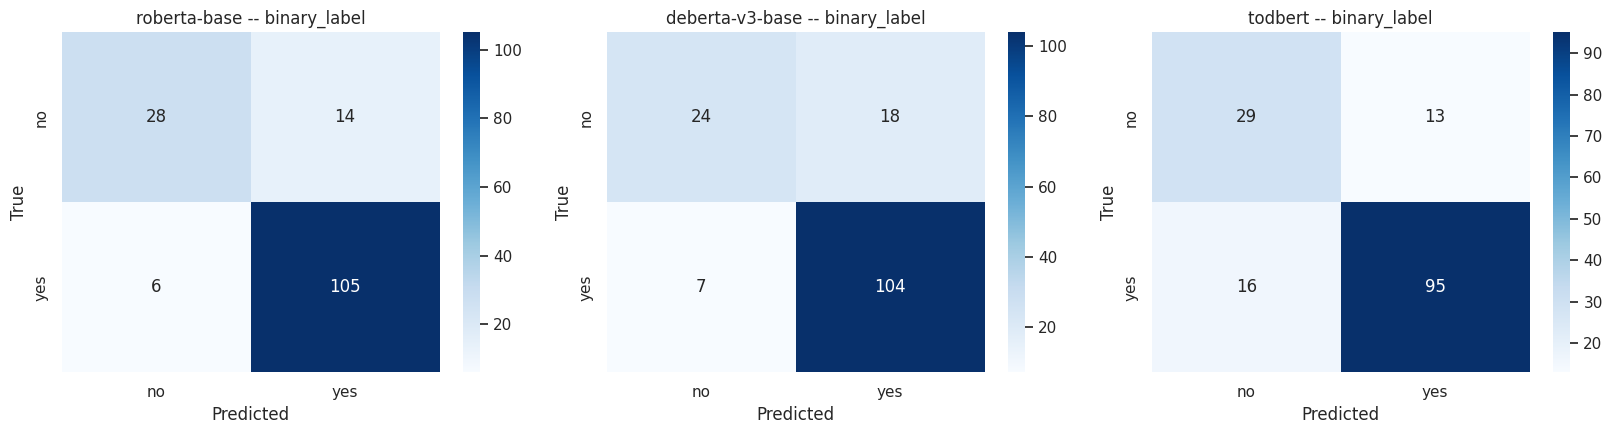

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_binary_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10d. Training curves — val F1 per epoch, per encoder

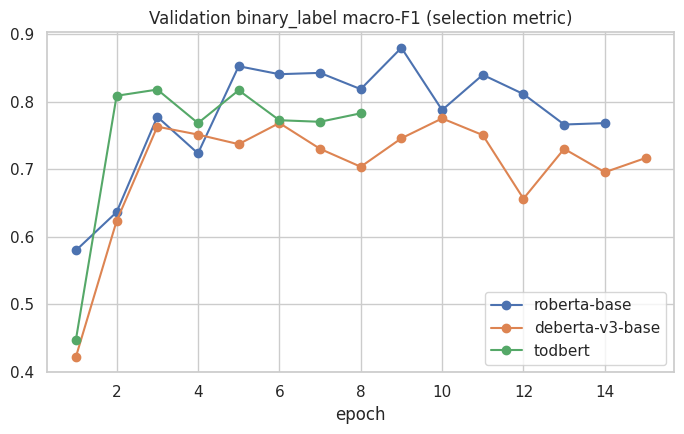

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    ax.plot(hist["epoch"], hist["val_binary_macro_f1"], marker="o", label=name)
ax.set_title("Validation binary_label macro-F1 (selection metric)")
ax.set_xlabel("epoch")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"training_curves_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()


## 10e. Classification reports (full precision/recall/F1 per class)

In [19]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))



roberta-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.82      0.67      0.74        42
         yes       0.88      0.95      0.91       111

    accuracy                           0.87       153
   macro avg       0.85      0.81      0.82       153
weighted avg       0.87      0.87      0.86       153


deberta-v3-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.77      0.57      0.66        42
         yes       0.85      0.94      0.89       111

    accuracy                           0.84       153
   macro avg       0.81      0.75      0.78       153
weighted avg       0.83      0.84      0.83       153


todbert -- binary_label classification report
              precision    recall  f1-score   support

          no       0.64      0.69      0.67        42
         yes       0.88      0.86      0.87       111

    accuracy                

## 11. Summary

Binary-only rerun of v10-Coda's gated hierarchical architecture, per the
instructor's review: modifier head removed, its capacity budget moved to
the binary head, its share of the contrastive loss moved to the binary
representation, and checkpoint selection now reads binary_macro_f1
directly instead of an average that a noisy modifier score could drag
down.

**Compare against, printed by the results cell above, not hardcoded
here:**

- v10-Coda's own per-encoder binary macro-F1 (test): RoBERTa 0.834,
  DeBERTa-v3 0.800, TOD-BERT 0.776 — did any of these move, and in which
  direction?
- The majority-class baseline (binary_macro_f1 = 0.4205) — the floor
  every version of this project has cleared by a wide margin.

**Honest limitation carried over from the intro cell**: augmentation
still oversamples what used to be modifier-minority (`conditional`/
`deferred`) rows, which are all `binary_label="yes"` — a leftover from
the two-task era that this notebook does not correct, so any regression
specifically on the `no` class deserves a second look before blaming the
architecture change itself. Retargeting augmentation at binary-minority
oversampling (`no`) instead is the natural next step if this notebook's
own numbers suggest augmentation, not architecture, is now the bottleneck.
